In [2]:
#### Análisis de respuesta comunitaria en anime y clasificación de alta puntuación ####

## Descripción del proyecto

# Este proyecto utiliza un dataset público de anime para estudiar cómo distintas características de recepción comunitaria se relacionan con las puntuaciones de los títulos. Entre las variables analizadas se incluyen el número de usuarios que calificaron cada anime, el número de usuarios que lo agregaron a sus listas, el tipo de anime, el rating, la cantidad de episodios y los géneros.

# Primero se realiza una exploración inicial del dataset, limpieza de valores faltantes y selección de variables relevantes. Después se crea la variable objetivo `high_score`, definida como 1 cuando un anime tiene una puntuación igual o superior a 8, y 0 en caso contrario.

# Posteriormente se preparan las variables predictoras mediante codificación de variables categóricas y codificación multilabel para los géneros. La variable `rank` se excluye del modelo porque está directamente relacionada con `score`, lo que podría generar fuga de información y producir resultados artificialmente altos.

# Finalmente se entrena un modelo XGBoost. A diferencia de un entrenamiento básico, el modelo se optimiza mediante GridSearchCV usando ROC-AUC como criterio de selección. Luego se evalúa con predicciones por probabilidad, ajuste de threshold, F1-score, matriz de confusión y curva ROC, prestando especial atención al desempeño sobre la clase minoritaria `high_score`.

# Qué señales de respuesta comunitaria y características generales permiten distinguir a los animes con alta puntuación, y qué tan bien puede un modelo XGBoost optimizado clasificarlos?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
from xgboost import XGBClassifier

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("anime-standalone.csv")
df.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,49.0,2051529,1059425,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,240.0,411130,231859,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,419.0,832704,400891,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969.jpg,7.25,3527.0,129287,46530,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,7.01,4893.0,16881,7226,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


In [9]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape:
(24923, 18)

Column names:
['id', 'title', 'titleJa', 'titleEn', 'image', 'mean', 'rank', 'num_list_users', 'num_scoring_users', 'num_episodes', 'start_date', 'end_date', 'media_type', 'status', 'rating', 'average_episode_duration', 'genres', 'studios']

Data types:
id                            int64
title                           str
titleJa                         str
titleEn                         str
image                           str
mean                        float64
rank                        float64
num_list_users                int64
num_scoring_users             int64
num_episodes                  int64
start_date                      str
end_date                        str
media_type                      str
status                          str
rating                          str
average_episode_duration      int64
genres                          str
studios                         str
dtype: object


In [50]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percentage": missing_percentage
})

missing_summary[missing_summary["missing_values"] > 0]

,missing_values,missing_percentage
rank,4758,25.169276
studios,3852,20.376640
rating,79,0.417901


In [10]:
df["score"] = df["mean"]

In [11]:
df.shape

(24923, 19)

In [12]:
df.columns.tolist()

['id',
 'title',
 'titleJa',
 'titleEn',
 'image',
 'mean',
 'rank',
 'num_list_users',
 'num_scoring_users',
 'num_episodes',
 'start_date',
 'end_date',
 'media_type',
 'status',
 'rating',
 'average_episode_duration',
 'genres',
 'studios',
 'score']

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24923 entries, 0 to 24922
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        24923 non-null  int64  
 1   title                     24923 non-null  str    
 2   titleJa                   24827 non-null  str    
 3   titleEn                   11964 non-null  str    
 4   image                     24817 non-null  str    
 5   mean                      18938 non-null  float64
 6   rank                      18157 non-null  float64
 7   num_list_users            24923 non-null  int64  
 8   num_scoring_users         24923 non-null  int64  
 9   num_episodes              24923 non-null  int64  
 10  start_date                24923 non-null  str    
 11  end_date                  24298 non-null  str    
 12  media_type                24923 non-null  str    
 13  status                    24923 non-null  str    
 14  rating           

In [14]:
df.describe(include="all")

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios,score
count,24923.000000,24923,24827,11964,24817,18938.000000,18157.000000,2.492300e+04,2.492300e+04,24923.000000,24923,24298,24923,24923,24639,24923.000000,24855,17030,18938.000000
unique,NaN,24918,23855,11811,24817,NaN,NaN,NaN,NaN,NaN,9653,9599,10,3,6,NaN,5346,1961,NaN
top,NaN,Geomjeong Gomusin,おしりたんてい,Way of Choices,https://myanimelist.net/images/anime/4/19644.jpg,NaN,NaN,NaN,NaN,NaN,2026-07,2023-03-24,tv,finished_airing,pg_13,NaN,Music,Toei Animation,NaN
freq,NaN,2,10,6,1,NaN,NaN,NaN,NaN,NaN,51,23,6487,24405,10565,NaN,1961,846,NaN
mean,33142.585283,NaN,NaN,NaN,NaN,6.480900,9710.065374,4.681139e+04,2.369004e+04,11.160173,NaN,NaN,NaN,NaN,NaN,1335.280303,NaN,NaN,6.480900
std,20700.031545,NaN,NaN,NaN,NaN,0.861085,6135.467997,1.849981e+05,1.100954e+05,44.244001,NaN,NaN,NaN,NaN,NaN,1529.406797,NaN,NaN,0.861085
min,1.000000,NaN,NaN,NaN,NaN,1.890000,1.000000,2.100000e+01,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.890000
25%,10935.500000,NaN,NaN,NaN,NaN,5.870000,4544.000000,4.050000e+02,1.160000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,229.000000,NaN,NaN,5.870000
50%,36575.000000,NaN,NaN,NaN,NaN,6.460000,9120.000000,2.004000e+03,6.340000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,1099.000000,NaN,NaN,6.460000
75%,52403.500000,NaN,NaN,NaN,NaN,7.100000,14115.000000,1.409650e+04,5.266500e+03,12.000000,NaN,NaN,NaN,NaN,NaN,1500.000000,NaN,NaN,7.100000


In [15]:
df.isnull().sum().sort_values(ascending=False).head(20)

titleEn                     12959
studios                      7893
rank                         6766
score                        5985
mean                         5985
end_date                      625
rating                        284
image                         106
titleJa                        96
genres                         68
id                              0
title                           0
num_episodes                    0
num_scoring_users               0
num_list_users                  0
start_date                      0
media_type                      0
status                          0
average_episode_duration        0
dtype: int64

In [16]:
selected_columns = [
    "title",
    "media_type",
    "num_episodes",
    "status",
    "rating",
    "score",
    "num_scoring_users",
    "rank",
    "num_list_users",
    "genres",
    "studios",
    "start_date"
]

df = df[selected_columns]

df.head()

,title,media_type,num_episodes,status,rating,score,num_scoring_users,rank,num_list_users,genres,studios,start_date
0,Cowboy Bebop,tv,26,finished_airing,r,8.75,1059425,49.0,2051529,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise,1998-04-03
1,Cowboy Bebop: Tengoku no Tobira,movie,1,finished_airing,r,8.38,231859,240.0,411130,"Action, Adult Cast, Sci-Fi, Space",Bones,2001-09-01
2,Trigun,tv,26,finished_airing,pg_13,8.22,400891,419.0,832704,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse,1998-04-01
3,Witch Hunter Robin,tv,26,finished_airing,pg_13,7.25,46530,3527.0,129287,"Action, Detective, Drama, Mystery, Supernatural",Sunrise,2002-07-03
4,Bouken Ou Beet,tv,52,finished_airing,pg,7.01,7226,4893.0,16881,"Action, Adventure, Fantasy, Shounen",Toei Animation,2004-09-30


In [17]:
df.isnull().sum().sort_values(ascending=False)

studios              7893
rank                 6766
score                5985
rating                284
genres                 68
num_episodes            0
media_type              0
title                   0
status                  0
num_scoring_users       0
num_list_users          0
start_date              0
dtype: int64

In [18]:
df = df.dropna(subset=["score"])
df = df.dropna(subset=["genres"])
df.isnull().sum()

title                   0
media_type              0
num_episodes            0
status                  0
rating                 79
score                   0
num_scoring_users       0
rank                 4758
num_list_users          0
genres                  0
studios              3852
start_date              0
dtype: int64

In [19]:
df["high_score"] = (df["score"] >= 8).astype(int)

In [20]:
df["high_score"].value_counts()

high_score
0    18139
1      765
Name: count, dtype: int64

In [21]:
# “El dataset presenta desbalance de clases, lo cual refleja la distribución real de puntuaciones en anime”

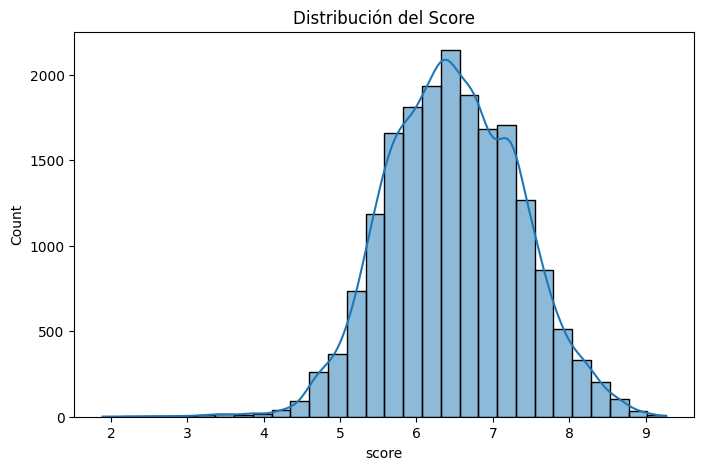

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["score"], bins=30, kde=True)
plt.title("Distribución del Score")
plt.show()

In [23]:
# La distribución del score presenta una forma aproximadamente normal, con la mayoría de los valores concentrados entre 6 y 7.5. La distribución del score muestra que la mayoría de los animes se concentran en calificaciones medias, mientras que los scores altos son menos frecuentes. 

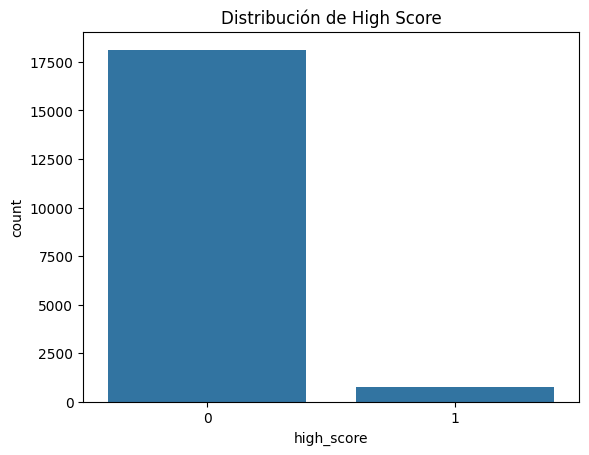

In [24]:
sns.countplot(x="high_score", data=df)
plt.title("Distribución de High Score")
plt.show()

In [25]:
# La variable high_score está desbalanceada: solo una minoría de animes alcanza score ≥ 8. Desde la perspectiva del proyecto, esto es relevante porque muestra que la validación comunitaria fuerte no es común; solo ciertos títulos logran concentrar una recepción suficientemente alta.

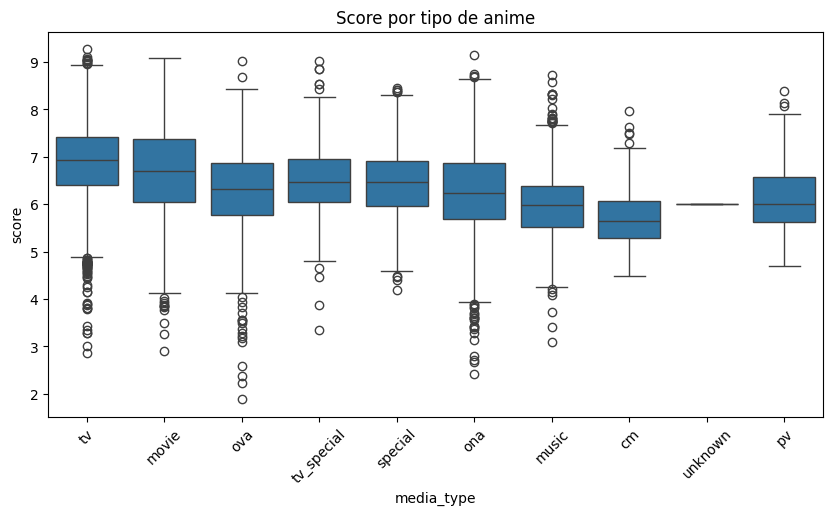

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(x="media_type", y="score", data=df)
plt.xticks(rotation=45)
plt.title("Score por tipo de anime")
plt.show()

In [27]:
# El análisis por tipo de anime permite observar si ciertos formatos concentran mejores niveles de recepción comunitaria. Aunque existen diferencias entre categorías, estas no parecen explicar por sí solas la alta puntuación, por lo que deben interpretarse junto con variables de posicionamiento y participación de usuarios.

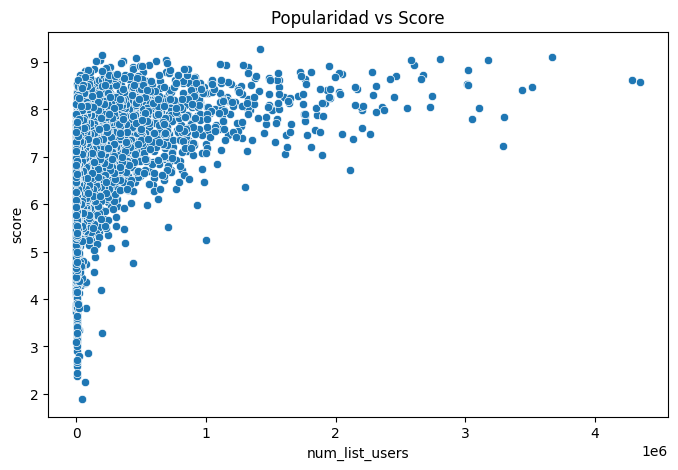

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="num_list_users", y="score", data=df)
plt.title("Popularidad vs Score")
plt.show()

In [29]:
# La relación entre num_list_users y score muestra una tendencia positiva con alta dispersión. Esto indica que la popularidad por sí sola no garantiza alta puntuación, pero sí forma parte de las señales de recepción comunitaria que pueden ayudar a distinguir animes mejor posicionados.

In [30]:
df["genres"].head()

0    Action, Adult Cast, Award Winning, Sci-Fi, Space
1                   Action, Adult Cast, Sci-Fi, Space
2      Action, Adult Cast, Adventure, Sci-Fi, Shounen
3     Action, Detective, Drama, Mystery, Supernatural
4                 Action, Adventure, Fantasy, Shounen
Name: genres, dtype: str

In [31]:
df["genres_list"] = df["genres"].apply(lambda x: x.split(", "))

In [32]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genres_encoded = mlb.fit_transform(df["genres_list"])

In [33]:
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

In [34]:
df = pd.concat([df, genres_df], axis=1)

In [35]:
df.head()

,title,media_type,num_episodes,status,rating,score,num_scoring_users,rank,num_list_users,genres,...,Survival,Suspense,Team Sports,Time Travel,Urban Fantasy,Vampire,Video Game,Villainess,Visual Arts,Workplace
0,Cowboy Bebop,tv,26.0,finished_airing,r,8.75,1059425.0,49.0,2051529.0,"Action, Adult Cast, Award Winning, Sci-Fi, Space",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cowboy Bebop: Tengoku no Tobira,movie,1.0,finished_airing,r,8.38,231859.0,240.0,411130.0,"Action, Adult Cast, Sci-Fi, Space",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Trigun,tv,26.0,finished_airing,pg_13,8.22,400891.0,419.0,832704.0,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Witch Hunter Robin,tv,26.0,finished_airing,pg_13,7.25,46530.0,3527.0,129287.0,"Action, Detective, Drama, Mystery, Supernatural",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Bouken Ou Beet,tv,52.0,finished_airing,pg,7.01,7226.0,4893.0,16881.0,"Action, Adventure, Fantasy, Shounen",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:

df = pd.read_csv("anime-standalone.csv")

df["score"] = df["mean"]

df = df[
    [
        "title",
        "media_type",
        "num_episodes",
        "status",
        "rating",
        "score",
        "num_scoring_users",
        "rank",
        "num_list_users",
        "genres",
        "studios",
        "start_date"
    ]
].copy()

df = df.dropna(subset=["score", "genres"]).copy()
df = df.reset_index(drop=True)

df["high_score"] = (df["score"] >= 8).astype(int)

df["genres_list"] = df["genres"].apply(lambda x: x.split(", "))

mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df["genres_list"])

genres_df = pd.DataFrame(
    genres_encoded,
    columns=mlb.classes_,
    index=df.index
)

df_model = pd.concat([df, genres_df], axis=1)

df_model.head()

,title,media_type,num_episodes,status,rating,score,num_scoring_users,rank,num_list_users,genres,...,Survival,Suspense,Team Sports,Time Travel,Urban Fantasy,Vampire,Video Game,Villainess,Visual Arts,Workplace
0,Cowboy Bebop,tv,26,finished_airing,r,8.75,1059425,49.0,2051529,"Action, Adult Cast, Award Winning, Sci-Fi, Space",...,0,0,0,0,0,0,0,0,0,0
1,Cowboy Bebop: Tengoku no Tobira,movie,1,finished_airing,r,8.38,231859,240.0,411130,"Action, Adult Cast, Sci-Fi, Space",...,0,0,0,0,0,0,0,0,0,0
2,Trigun,tv,26,finished_airing,pg_13,8.22,400891,419.0,832704,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",...,0,0,0,0,0,0,0,0,0,0
3,Witch Hunter Robin,tv,26,finished_airing,pg_13,7.25,46530,3527.0,129287,"Action, Detective, Drama, Mystery, Supernatural",...,0,0,0,0,0,0,0,0,0,0
4,Bouken Ou Beet,tv,52,finished_airing,pg,7.01,7226,4893.0,16881,"Action, Adventure, Fantasy, Shounen",...,0,0,0,0,0,0,0,0,0,0


In [37]:
df_model = df_model.drop(columns=[
    "title",
    "genres",
    "genres_list",
    "studios",
    "start_date",
    "rank"
])

In [38]:
df_model = pd.get_dummies(
    df_model,
    columns=["media_type", "status", "rating"],
    drop_first=True
)

In [39]:
X = df_model.drop(columns=["high_score", "score"])
y = df_model["high_score"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    roc_curve
)

import matplotlib.pyplot as plt
import numpy as np

In [42]:
param_grid = {
    "n_estimators": [100, 200, 500, 1000],
    "max_depth": [6, 8, 10, 12],
    "learning_rate": [0.001, 0.1],
    "subsample": [0.8, 1.0]
}

gs = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    verbose=1
)

gs.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.1], 'max_depth': [6, 8, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [43]:
gs.best_estimator_

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [44]:
anime_model = gs.best_estimator_

In [45]:
y_proba = anime_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.9666545964214426


In [46]:
percentiles = np.arange(0.1, 1.0, 0.05)

best_f1 = 0
best_threshold = 0

for p in percentiles:
    threshold = np.percentile(y_proba, p * 100)
    y_pred_threshold = (y_proba >= threshold).astype(int)

    f1 = f1_score(y_test, y_pred_threshold)
    auc_score = roc_auc_score(y_test, y_proba)

    print(
        f"Percentil {int(p*100)} | "
        f"Threshold: {threshold:.3f} | "
        f"AUC: {auc_score:.3f} | "
        f"F1: {f1:.3f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nMejor threshold:")
print(best_threshold)

print("\nMejor F1:")
print(best_f1)

Percentil 10 | Threshold: 0.000 | AUC: 0.967 | F1: 0.086
Percentil 15 | Threshold: 0.000 | AUC: 0.967 | F1: 0.090
Percentil 20 | Threshold: 0.000 | AUC: 0.967 | F1: 0.096
Percentil 25 | Threshold: 0.000 | AUC: 0.967 | F1: 0.102
Percentil 30 | Threshold: 0.000 | AUC: 0.967 | F1: 0.109
Percentil 35 | Threshold: 0.000 | AUC: 0.967 | F1: 0.117
Percentil 40 | Threshold: 0.000 | AUC: 0.967 | F1: 0.126
Percentil 45 | Threshold: 0.000 | AUC: 0.967 | F1: 0.137
Percentil 50 | Threshold: 0.001 | AUC: 0.967 | F1: 0.150
Percentil 55 | Threshold: 0.001 | AUC: 0.967 | F1: 0.165
Percentil 60 | Threshold: 0.001 | AUC: 0.967 | F1: 0.184
Percentil 65 | Threshold: 0.002 | AUC: 0.967 | F1: 0.207
Percentil 70 | Threshold: 0.005 | AUC: 0.967 | F1: 0.238
Percentil 75 | Threshold: 0.009 | AUC: 0.967 | F1: 0.277
Percentil 80 | Threshold: 0.018 | AUC: 0.967 | F1: 0.326
Percentil 85 | Threshold: 0.037 | AUC: 0.967 | F1: 0.397
Percentil 90 | Threshold: 0.092 | AUC: 0.967 | F1: 0.482
Percentil 95 | Threshold: 0.234

In [47]:
y_pred_best = (y_proba >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3628
           1       0.49      0.60      0.54       153

    accuracy                           0.96      3781
   macro avg       0.73      0.79      0.76      3781
weighted avg       0.96      0.96      0.96      3781

Confusion Matrix:
[[3531   97]
 [  61   92]]


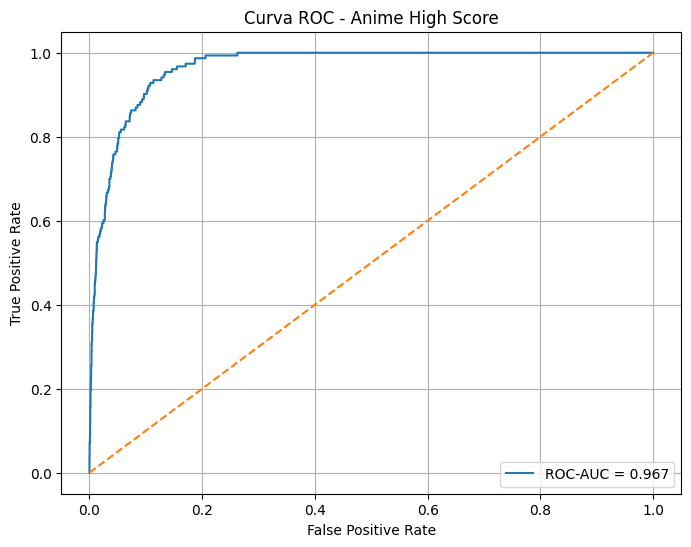

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Anime High Score")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
## Conclusión

Este proyecto analizó un dataset público de anime para identificar patrones asociados con títulos de alta puntuación. Durante el análisis exploratorio se revisaron variables como el número de usuarios que calificaron cada anime, el número de usuarios que lo agregaron a sus listas, el tipo de anime, el rating, el número de episodios y los géneros.

A partir de la variable `score`, se creó la variable objetivo `high_score`, que clasifica los animes con puntuación igual o superior a 8 como casos positivos. Esta decisión permitió transformar el análisis en un problema de clasificación supervisada.

El dataset presentó un desbalance importante entre clases, ya que la mayoría de los animes no pertenecen a la categoría `high_score`. Por esta razón, la evaluación del modelo no se basó únicamente en accuracy, sino también en métricas más adecuadas para este contexto, como ROC-AUC, F1-score, precision, recall y matriz de confusión.

Para mejorar el procedimiento de modelado, se entrenó un modelo XGBoost optimizado mediante GridSearchCV, utilizando ROC-AUC como métrica principal de selección. Después se trabajó con las probabilidades predichas por el modelo y se ajustó el threshold de clasificación para buscar un mejor balance en el F1-score.

Una decisión importante fue excluir la variable `rank` del modelo. Aunque puede ser útil durante el análisis exploratorio, está fuertemente relacionada con `score`. Como `high_score` fue construida a partir de `score`, incluir `rank` podría generar fuga de información y resultados artificialmente altos.

Los resultados muestran que las variables de participación comunitaria, junto con características generales como tipo de anime, rating, episodios y géneros, aportan información útil para distinguir animes con alta puntuación. Sin embargo, debido al desbalance de clases, el modelo tiene más dificultad para identificar correctamente la clase minoritaria, lo cual se refleja en métricas como recall y F1-score.

En general, el proyecto muestra un flujo completo de Ciencia de Datos: carga de datos, limpieza, análisis 

SyntaxError: invalid syntax (1060629208.py, line 3)